# Portfolio Risk Analysis

The previous notebooks focused on portfolio construction and optimization. In this notebook, I evaluate the risk of the optimized portfolios using several risk measures.

I consider the Sharpe ratio, maximum drawdown, Value at Risk (VaR), and Conditional Value at Risk (CVaR).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize

## 1. Data and Portfolio Construction

I use the same assets and historical period as in the previous notebooks. The minimum-variance and maximum-Sharpe portfolios are reconstructed using the same long-only constraints.

In [2]:
tickers = [
    "AAPL",
    "MSFT",
    "JPM",
    "JNJ",
    "XOM",
    "PG",
    "CAT",
    "NEE"
]

start_date = "2016-01-01"
end_date = "2026-01-01"

data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

prices = data["Close"]
returns = prices.pct_change().dropna()

mu = returns.mean() * 252
cov_matrix = returns.cov() * 252

n_assets = len(tickers)
risk_free_rate = 0.0

constraints = {
    "type": "eq",
    "fun": lambda weights: np.sum(weights) - 1
}

bounds = [(0, 1)] * n_assets
initial_weights = np.ones(n_assets) / n_assets

In [3]:
def portfolio_variance(weights):
    return weights @ cov_matrix @ weights


def negative_sharpe(weights):
    portfolio_return = weights @ mu
    portfolio_volatility = np.sqrt(
        weights @ cov_matrix @ weights
    )

    return -(
        (portfolio_return - risk_free_rate)
        / portfolio_volatility
    )


min_var_result = minimize(
    portfolio_variance,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

max_sharpe_result = minimize(
    negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

min_var_weights = min_var_result.x
max_sharpe_weights = max_sharpe_result.x
equal_weights = initial_weights

## 2. Historical Portfolio Returns

Using the estimated portfolio weights, I calculate the historical daily returns of the equal-weight, minimum-variance, and maximum-Sharpe portfolios.

In [4]:
portfolio_returns = pd.DataFrame({
    "Equal Weight": returns @ equal_weights,
    "Minimum Variance": returns @ min_var_weights,
    "Maximum Sharpe": returns @ max_sharpe_weights
})

portfolio_returns.head()

,Equal Weight,Minimum Variance,Maximum Sharpe
Date,,,
2016-01-05,-0.000446,0.003810,-0.004553
2016-01-06,-0.011777,-0.008493,-0.013793
2016-01-07,-0.022980,-0.013486,-0.027555
2016-01-08,-0.008285,-0.011106,-0.002367
2016-01-11,-0.002619,-0.001300,-0.004255


## 3. Sharpe Ratio

The Sharpe ratio measures expected excess return per unit of volatility. A higher Sharpe ratio indicates greater return relative to the amount of risk taken.

For consistency with the previous notebooks, I assume a risk-free rate of zero.

In [5]:
annual_returns = portfolio_returns.mean() * 252

annual_volatility = (
    portfolio_returns.std() * np.sqrt(252)
)

sharpe_ratios = (
    annual_returns - risk_free_rate
) / annual_volatility

sharpe_summary = pd.DataFrame({
    "Annual Return": annual_returns,
    "Annual Volatility": annual_volatility,
    "Sharpe Ratio": sharpe_ratios
})

sharpe_summary

,Annual Return,Annual Volatility,Sharpe Ratio
Equal Weight,0.198329,0.171669,1.155300
Minimum Variance,0.140365,0.151382,0.927225
Maximum Sharpe,0.241706,0.193845,1.246905


## 4. Maximum Drawdown

Maximum drawdown measures the largest percentage decline from a previous portfolio peak to a subsequent trough.

Unlike volatility, drawdown focuses on the realized loss an investor would have experienced during the worst decline in portfolio value.

In [6]:
cumulative_returns = (1 + portfolio_returns).cumprod()

running_max = cumulative_returns.cummax()

drawdowns = (
    cumulative_returns / running_max
) - 1

max_drawdowns = drawdowns.min()

max_drawdowns

Equal Weight       -0.330507
Minimum Variance   -0.290115
Maximum Sharpe     -0.308752
dtype: float64

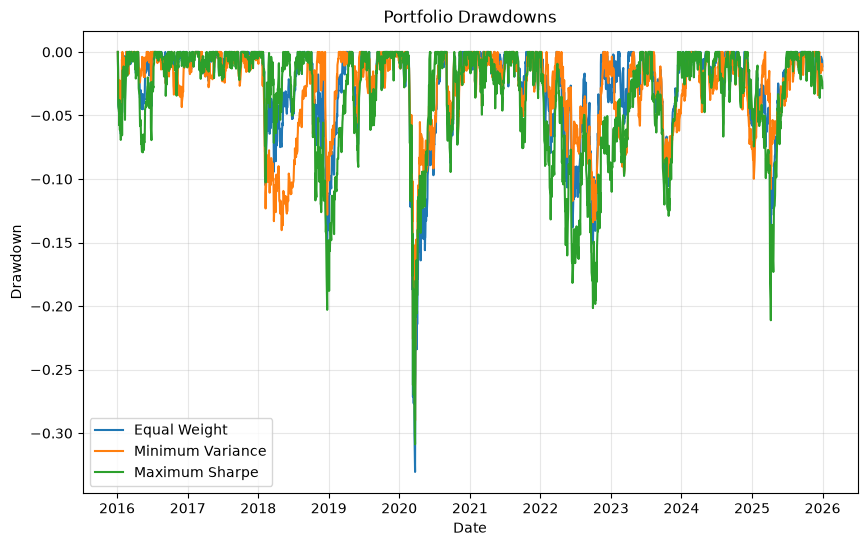

In [7]:
plt.figure(figsize=(10, 6))

for portfolio in drawdowns.columns:
    plt.plot(
        drawdowns.index,
        drawdowns[portfolio],
        label=portfolio
    )

plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.title("Portfolio Drawdowns")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 5. Value at Risk (VaR)

Historical Value at Risk estimates a loss threshold using the empirical distribution of past portfolio returns.

I calculate the 95% one-day VaR. This corresponds to the 5th percentile of historical daily returns.

In [8]:
confidence_level = 0.95

var_95 = portfolio_returns.quantile(
    1 - confidence_level
)

var_95

Equal Weight       -0.015087
Minimum Variance   -0.012987
Maximum Sharpe     -0.018388
Name: 0.050000000000000044, dtype: float64

## 6. Conditional Value at Risk (CVaR)

VaR identifies a loss threshold but does not describe how severe losses can be beyond that threshold.

Conditional Value at Risk (CVaR), also called Expected Shortfall, measures the average return among observations that fall below the VaR threshold.

In [9]:
cvar_95 = pd.Series(index=portfolio_returns.columns, dtype=float)

for portfolio in portfolio_returns.columns:
    threshold = var_95[portfolio]

    cvar_95[portfolio] = portfolio_returns.loc[
        portfolio_returns[portfolio] <= threshold,
        portfolio
    ].mean()

cvar_95

Equal Weight       -0.025300
Minimum Variance   -0.021828
Maximum Sharpe     -0.028549
dtype: float64

## 7. Risk Summary

I combine the risk measures to compare the three portfolio strategies.

In [10]:
risk_summary = pd.DataFrame({
    "Sharpe Ratio": sharpe_ratios,
    "Maximum Drawdown": max_drawdowns,
    "95% VaR": var_95,
    "95% CVaR": cvar_95
})

risk_summary

,Sharpe Ratio,Maximum Drawdown,95% VaR,95% CVaR
Equal Weight,1.155300,-0.330507,-0.015087,-0.025300
Minimum Variance,0.927225,-0.290115,-0.012987,-0.021828
Maximum Sharpe,1.246905,-0.308752,-0.018388,-0.028549


## 8. Return Distributions

The distribution of daily returns provides a visual comparison of the downside risk and dispersion of the three portfolios.

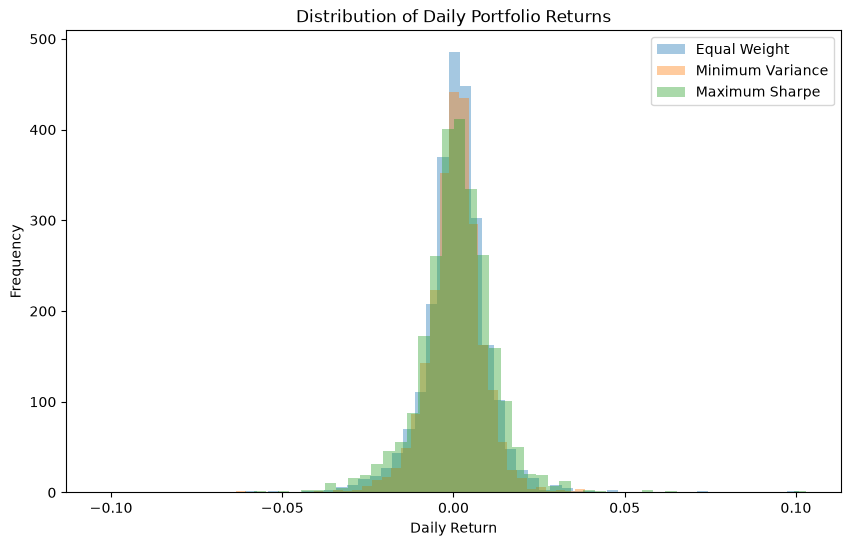

In [11]:
plt.figure(figsize=(10, 6))

for portfolio in portfolio_returns.columns:
    plt.hist(
        portfolio_returns[portfolio],
        bins=60,
        alpha=0.4,
        label=portfolio
    )

plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Portfolio Returns")
plt.legend()

plt.show()

## 9. Conclusion

Different risk measures capture different aspects of portfolio risk. Volatility measures overall return variability, while maximum drawdown measures the largest realized peak-to-trough decline. VaR estimates a downside threshold, and CVaR provides additional information about the severity of losses beyond that threshold.

The optimized portfolios may perform well according to the historical data used to construct them, but these results are in-sample. Historical risk estimates and optimized weights do not guarantee similar future performance.

For this reason, the next step is to evaluate the strategies using rolling out-of-sample backtesting.